## Merge Json and Save to CSV

📂 Looking for JSON files in: ..\data\pending
💾 Output will be saved to: ..\data\synthetic\five_email_phishing_synthetic_raw.csv.gz
⚖️  Balanced dataset will be saved to: ..\data\synthetic\five_email_phishing_synthetic.csv.gz
🎯 Target balanced size: 2,000 samples (1,000 per class)

🔍 Found 1 JSON files:
  - phishing and social engineering via deceptive email content_scale.json

📊 Processing files...

🔄 Processing: phishing and social engineering via deceptive email content_scale.json
  📈 Samples: 2150, Label distribution: {1: 1075, 0: 1075}

✅ Successfully processed 1 files

🔗 Merging 1 DataFrames...
📊 Merged DataFrame Info:
  - Total samples: 2,150
  - Total columns: 8
  - Memory usage: 1.89 MB

📋 DataFrame Structure:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2150 entries, 0 to 2149
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   subject               2150 non-null   object 
 1   body    

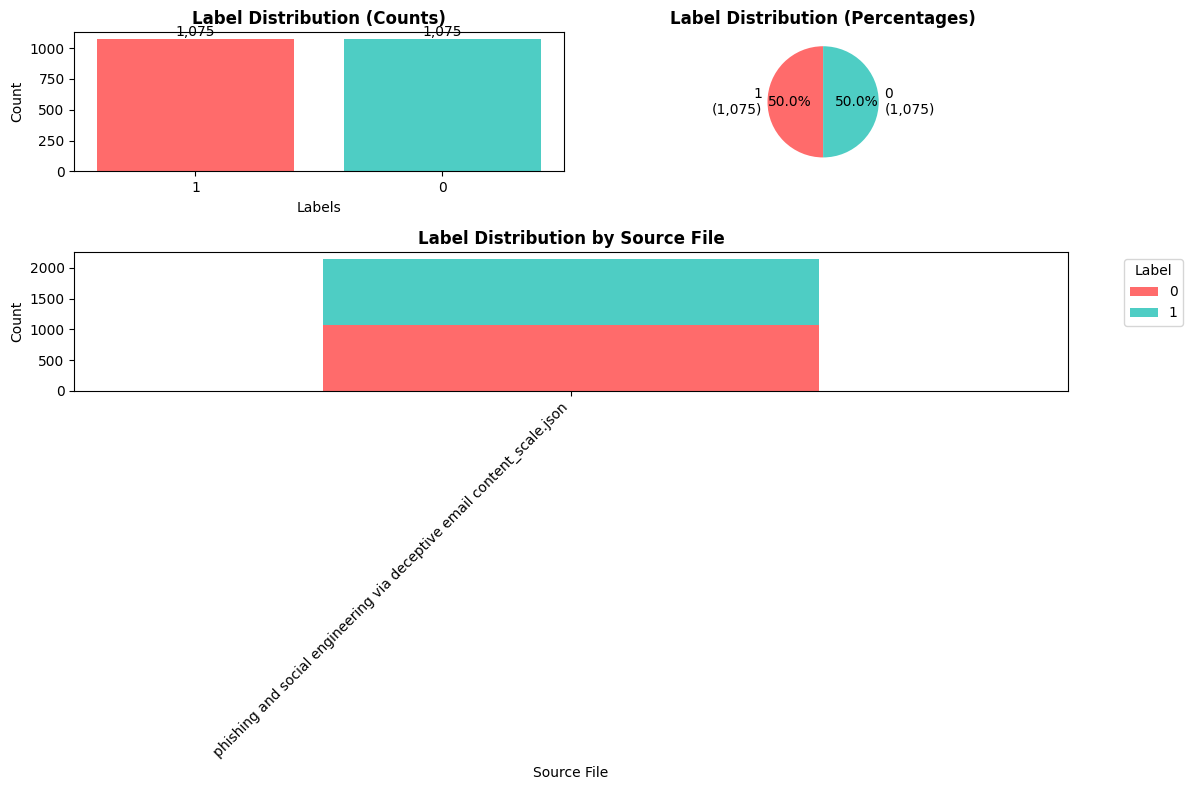


📈 Additional Statistics:
  - Total unique labels: 2
  - Most common label: 1 (1,075 samples)
  - Least common label: 0 (1,075 samples)
  - Class imbalance ratio: 1.00:1
  - Malicious samples (label=1): 1,075 (50.00%)
  - Benign samples (label=0): 1,075 (50.00%)

👀 Sample Data (first 5 rows):
                                             subject  \
0  FDA Approved Medications Now at 65% OFF - Limi...   
1  Research Grant Application Submission Confirma...   
2  Part-Time Work From Home Offer - Earn $2200 We...   
3  Work From Home - Earn $2000/week with Flexible...   
4  Project Update: Software Development Lifecycle...   

                                                body  label   source  \
0  Hello Dear Customer,\n\nGet genuine FDA approv...      1  TREC-07   
1  Dear Dr. Patel,\n\nWe are pleased to confirm t...      0  TREC-07   
2  Dear Applicant,\n\nWe are urgently recruiting ...      1  TREC-07   
3  Dear Job Seeker,\n\nWe are hiring remote data ...      1  TREC-07   
4  Hi Tea

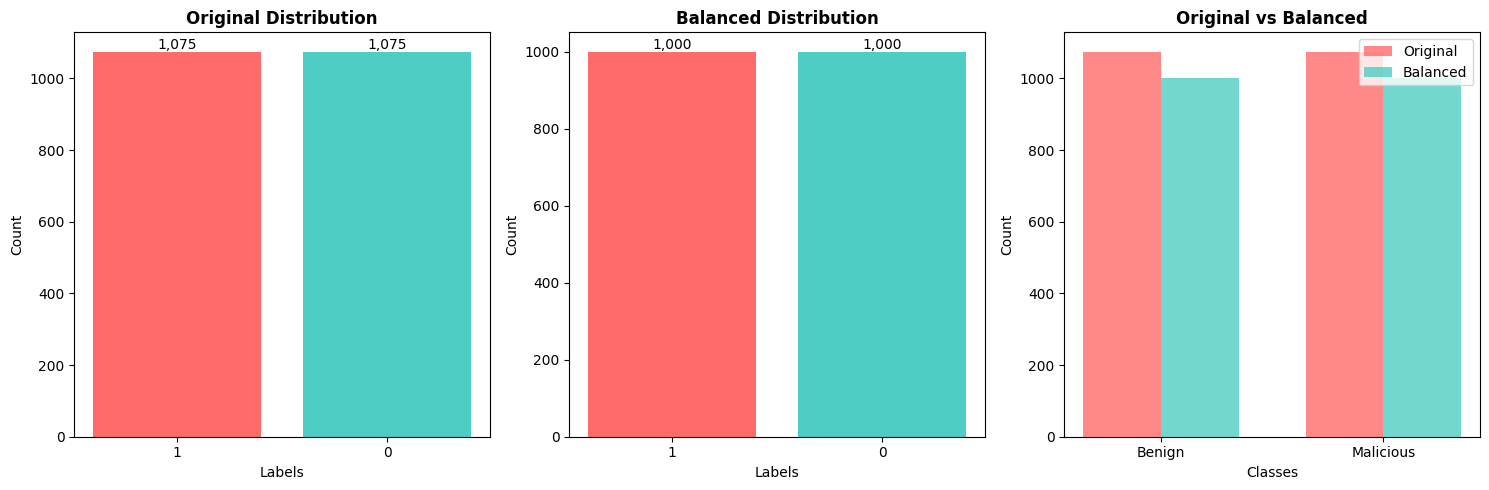


💾 Saving balanced dataset to: ..\data\synthetic\five_email_phishing_synthetic.csv.gz
✅ Balanced dataset saved successfully!
  - File size: 0.28 MB
  - Compression: gzip
  - Samples: 2,000
✅ Balanced file verification passed!

🏁 All processing complete!
📂 Files created:
  - Original merged: ..\data\synthetic\five_email_phishing_synthetic_raw.csv.gz
  - Balanced dataset: ..\data\synthetic\five_email_phishing_synthetic.csv.gz


In [1]:
# Merge Synthetic Cybersecurity Data
# Jupyter Notebook for merging JSON files from ../data/pending/ directory

import pandas as pd
import json
import gzip
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import numpy as np
from sklearn.utils import resample

# ===== CONFIGURATION =====
# Set the target sample size for balanced resampling
BALANCED_SAMPLE_SIZE = 2000  # Total samples in balanced dataset (N/2 per class)
CREATE_BALANCED_DATASET = True  # Set to False to skip balanced dataset creation

# Set up paths
pending_dir = Path("../data/pending/")
output_dir = Path("../data/synthetic/")
output_file = output_dir / "five_email_phishing_synthetic_raw.csv.gz"
balanced_output_file = output_dir / "five_email_phishing_synthetic.csv.gz"

# Ensure output directory exists
output_dir.mkdir(parents=True, exist_ok=True)

print(f"📂 Looking for JSON files in: {pending_dir}")
print(f"💾 Output will be saved to: {output_file}")
if CREATE_BALANCED_DATASET:
    print(f"⚖️  Balanced dataset will be saved to: {balanced_output_file}")
    print(f"🎯 Target balanced size: {BALANCED_SAMPLE_SIZE:,} samples ({BALANCED_SAMPLE_SIZE//2:,} per class)")

# Find all JSON files in the pending directory
json_files = list(pending_dir.glob("*.json"))
print(f"\n🔍 Found {len(json_files)} JSON files:")
for file in json_files:
    print(f"  - {file.name}")

if not json_files:
    print("❌ No JSON files found in the pending directory!")
    exit()

# Initialize list to store all DataFrames
dataframes = []
file_stats = []

print(f"\n📊 Processing files...")

# Process each JSON file
for json_file in json_files:
    print(f"\n🔄 Processing: {json_file.name}")
    
    try:
        # Load JSON file
        with open(json_file, 'r', encoding='utf-8') as f:
            data = json.load(f)
        
        # Extract samples based on CyberData structure
        if 'samples' in data:
            samples = data['samples']
        elif 'examples' in data:
            samples = data['examples']
        elif isinstance(data, list):
            samples = data
        else:
            print(f"⚠️  Warning: Unknown structure in {json_file.name}, treating as single sample")
            samples = [data]
        
        # Convert to DataFrame
        df = pd.DataFrame(samples)
        
        # Add metadata columns
        df['source_file'] = json_file.name
        df['file_index'] = len(dataframes)
        
        # Store stats
        stats = {
            'file': json_file.name,
            'samples': len(df),
            'columns': list(df.columns),
            'has_label': 'label' in df.columns
        }
        
        # Check label distribution if label column exists
        if 'label' in df.columns:
            label_dist = df['label'].value_counts().to_dict()
            stats['label_distribution'] = label_dist
            print(f"  📈 Samples: {len(df)}, Label distribution: {label_dist}")
        else:
            print(f"  📈 Samples: {len(df)}, No 'label' column found")
            # Check for other label-like columns
            label_candidates = [col for col in df.columns if 'label' in col.lower() or 'class' in col.lower()]
            if label_candidates:
                print(f"  🔍 Found potential label columns: {label_candidates}")
                stats['potential_labels'] = label_candidates
        
        file_stats.append(stats)
        dataframes.append(df)
        
    except Exception as e:
        print(f"❌ Error processing {json_file.name}: {str(e)}")
        continue

print(f"\n✅ Successfully processed {len(dataframes)} files")

if not dataframes:
    print("❌ No valid data found in any files!")
    exit()

# Merge all DataFrames
print(f"\n🔗 Merging {len(dataframes)} DataFrames...")
merged_df = pd.concat(dataframes, ignore_index=True, sort=False)

print(f"📊 Merged DataFrame Info:")
print(f"  - Total samples: {len(merged_df):,}")
print(f"  - Total columns: {len(merged_df.columns)}")
print(f"  - Memory usage: {merged_df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# Show DataFrame info
print(f"\n📋 DataFrame Structure:")
print(merged_df.info())

# Analyze label distribution
print(f"\n🎯 Label Distribution Analysis:")

# Check for label column
if 'label' in merged_df.columns:
    label_col = 'label'
elif 'Label' in merged_df.columns:
    label_col = 'Label'
else:
    # Find potential label columns
    label_candidates = [col for col in merged_df.columns if 
                       'label' in col.lower() or 'class' in col.lower() or 'target' in col.lower()]
    
    if label_candidates:
        label_col = label_candidates[0]
        print(f"🔍 Using '{label_col}' as label column")
    else:
        print("⚠️  No label column found!")
        label_col = None

if label_col:
    # Analyze label distribution
    label_counts = merged_df[label_col].value_counts()
    label_percentages = merged_df[label_col].value_counts(normalize=True) * 100
    
    print(f"\n📊 Label Distribution in '{label_col}' column:")
    print(f"{'Label':<15} {'Count':<10} {'Percentage':<12}")
    print("-" * 40)
    
    for label, count in label_counts.items():
        percentage = label_percentages[label]
        print(f"{str(label):<15} {count:<10,} {percentage:<11.2f}%")
    
    # Create visualization
    plt.figure(figsize=(12, 8))
    
    # Subplot 1: Count distribution
    plt.subplot(2, 2, 1)
    bars = plt.bar(range(len(label_counts)), label_counts.values, 
                   color=['#ff6b6b', '#4ecdc4', '#45b7d1', '#96ceb4', '#feca57'][:len(label_counts)])
    plt.title('Label Distribution (Counts)', fontweight='bold')
    plt.xlabel('Labels')
    plt.ylabel('Count')
    plt.xticks(range(len(label_counts)), [str(x) for x in label_counts.index])
    
    # Add value labels on bars
    for i, bar in enumerate(bars):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height):,}', ha='center', va='bottom')
    
    # Subplot 2: Percentage distribution
    plt.subplot(2, 2, 2)
    plt.pie(label_counts.values, labels=[f'{label}\n({count:,})' for label, count in label_counts.items()], 
            autopct='%1.1f%%', startangle=90,
            colors=['#ff6b6b', '#4ecdc4', '#45b7d1', '#96ceb4', '#feca57'][:len(label_counts)])
    plt.title('Label Distribution (Percentages)', fontweight='bold')
    
    # Subplot 3: Distribution by source file
    if 'source_file' in merged_df.columns:
        plt.subplot(2, 1, 2)
        file_label_crosstab = pd.crosstab(merged_df['source_file'], merged_df[label_col])
        file_label_crosstab.plot(kind='bar', stacked=True, ax=plt.gca(), 
                                color=['#ff6b6b', '#4ecdc4', '#45b7d1', '#96ceb4', '#feca57'])
        plt.title('Label Distribution by Source File', fontweight='bold')
        plt.xlabel('Source File')
        plt.ylabel('Count')
        plt.legend(title='Label', bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.xticks(rotation=45, ha='right')
    
    plt.tight_layout()
    plt.show()
    
    # Additional statistics
    print(f"\n📈 Additional Statistics:")
    print(f"  - Total unique labels: {merged_df[label_col].nunique()}")
    print(f"  - Most common label: {label_counts.index[0]} ({label_counts.iloc[0]:,} samples)")
    print(f"  - Least common label: {label_counts.index[-1]} ({label_counts.iloc[-1]:,} samples)")
    
    if len(label_counts) == 2:
        # Binary classification metrics
        imbalance_ratio = label_counts.max() / label_counts.min()
        print(f"  - Class imbalance ratio: {imbalance_ratio:.2f}:1")
        
        # Identify malicious vs benign based on typical encoding
        if set(label_counts.index) == {0, 1}:
            malicious_count = label_counts.get(1, 0)
            benign_count = label_counts.get(0, 0)
            malicious_ratio = malicious_count / len(merged_df) * 100
            print(f"  - Malicious samples (label=1): {malicious_count:,} ({malicious_ratio:.2f}%)")
            print(f"  - Benign samples (label=0): {benign_count:,} ({100-malicious_ratio:.2f}%)")

# Show sample data
print(f"\n👀 Sample Data (first 5 rows):")
display_columns = [col for col in merged_df.columns if col not in ['source_file', 'file_index']][:10]  # Show first 10 columns
print(merged_df[display_columns].head())

# Show file statistics
print(f"\n📁 File Processing Summary:")
print(f"{'File':<30} {'Samples':<10} {'Has Label':<12} {'Label Dist'}")
print("-" * 80)
for stat in file_stats:
    file_name = stat['file'][:28] + '..' if len(stat['file']) > 30 else stat['file']
    samples = stat['samples']
    has_label = "✅" if stat['has_label'] else "❌"
    
    if 'label_distribution' in stat:
        dist_str = str(stat['label_distribution'])[:30]
    else:
        dist_str = "No labels"
    
    print(f"{file_name:<30} {samples:<10,} {has_label:<12} {dist_str}")

# Save the merged DataFrame
print(f"\n💾 Saving merged data to: {output_file}")

try:
    # Save as compressed CSV
    merged_df.to_csv(output_file, index=False, compression='gzip')
    
    # Verify the saved file
    file_size_mb = output_file.stat().st_size / 1024**2
    print(f"✅ Successfully saved!")
    print(f"  - File size: {file_size_mb:.2f} MB")
    print(f"  - Compression: gzip")
    print(f"  - Format: CSV")
    
    # Test loading the saved file
    print(f"\n🧪 Testing saved file...")
    test_df = pd.read_csv(output_file, compression='gzip')
    print(f"✅ File loads correctly!")
    print(f"  - Loaded samples: {len(test_df):,}")
    print(f"  - Loaded columns: {len(test_df.columns)}")
    
    # Verify label distribution is preserved
    if label_col and label_col in test_df.columns:
        test_label_counts = test_df[label_col].value_counts()
        if test_label_counts.equals(label_counts):
            print(f"✅ Label distribution preserved correctly!")
        else:
            print(f"⚠️  Warning: Label distribution changed during save/load")
    
except Exception as e:
    print(f"❌ Error saving file: {str(e)}")

print(f"\n🎉 Processing complete!")
print(f"📊 Final Summary:")
print(f"  - Files processed: {len(file_stats)}")
print(f"  - Total samples: {len(merged_df):,}")
print(f"  - Output file: {output_file}")
print(f"  - Ready for machine learning: {'✅' if label_col else '❌'}")

# ===== CREATE BALANCED DATASET =====
if CREATE_BALANCED_DATASET and label_col:
    print(f"\n{'='*60}")
    print(f"⚖️  CREATING BALANCED DATASET")
    print(f"{'='*60}")
    
    # Check if we have binary classification
    unique_labels = merged_df[label_col].unique()
    print(f"🔍 Detected labels: {sorted(unique_labels)}")
    
    if len(unique_labels) == 2:
        print(f"✅ Binary classification detected - proceeding with balanced sampling")
        
        # Determine which labels are malicious/benign
        labels_sorted = sorted(unique_labels)
        
        # Assume binary encoding: 0=benign, 1=malicious (typical in cybersecurity)
        if set(unique_labels) == {0, 1}:
            benign_label, malicious_label = 0, 1
            print(f"📝 Using standard encoding: Benign={benign_label}, Malicious={malicious_label}")
        else:
            # Use the sorted order as fallback
            benign_label, malicious_label = labels_sorted[0], labels_sorted[1]
            print(f"📝 Using detected encoding: Benign={benign_label}, Malicious={malicious_label}")
        
        # Separate classes
        benign_samples = merged_df[merged_df[label_col] == benign_label]
        malicious_samples = merged_df[merged_df[label_col] == malicious_label]
        
        print(f"\n📊 Original Distribution:")
        print(f"  - Benign samples: {len(benign_samples):,}")
        print(f"  - Malicious samples: {len(malicious_samples):,}")
        print(f"  - Total samples: {len(merged_df):,}")
        
        # Calculate target size per class
        samples_per_class = BALANCED_SAMPLE_SIZE // 2
        
        print(f"\n🎯 Target Balanced Distribution:")
        print(f"  - Target per class: {samples_per_class:,}")
        print(f"  - Total target size: {BALANCED_SAMPLE_SIZE:,}")
        
        # Check if we have enough samples
        min_available = min(len(benign_samples), len(malicious_samples))
        
        if min_available < samples_per_class:
            print(f"⚠️  Warning: Not enough samples in minority class!")
            print(f"   Available: {min_available:,}, Needed: {samples_per_class:,}")
            print(f"   Using all available samples with oversampling...")
            
            # Use all samples from minority class and oversample if needed
            if len(benign_samples) < len(malicious_samples):
                # Benign is minority - oversample benign
                balanced_benign = resample(benign_samples, 
                                         n_samples=samples_per_class, 
                                         random_state=42,
                                         replace=True)
                balanced_malicious = resample(malicious_samples,
                                            n_samples=samples_per_class,
                                            random_state=42,
                                            replace=False)
                print(f"📈 Oversampled benign class from {len(benign_samples):,} to {samples_per_class:,}")
            else:
                # Malicious is minority - oversample malicious
                balanced_malicious = resample(malicious_samples,
                                            n_samples=samples_per_class,
                                            random_state=42,
                                            replace=True)
                balanced_benign = resample(benign_samples,
                                         n_samples=samples_per_class,
                                         random_state=42,
                                         replace=False)
                print(f"📈 Oversampled malicious class from {len(malicious_samples):,} to {samples_per_class:,}")
        else:
            print(f"✅ Sufficient samples available - using random undersampling")
            
            # Downsample both classes to target size
            balanced_benign = resample(benign_samples,
                                     n_samples=samples_per_class,
                                     random_state=42,
                                     replace=False)
            balanced_malicious = resample(malicious_samples,
                                        n_samples=samples_per_class,
                                        random_state=42,
                                        replace=False)
            print(f"📉 Downsampled benign: {len(benign_samples):,} → {samples_per_class:,}")
            print(f"📉 Downsampled malicious: {len(malicious_samples):,} → {samples_per_class:,}")
        
        # Combine balanced classes
        balanced_df = pd.concat([balanced_benign, balanced_malicious], ignore_index=True)
        
        # Shuffle the balanced dataset
        balanced_df = balanced_df.sample(frac=1, random_state=42).reset_index(drop=True)
        
        print(f"\n✅ Balanced Dataset Created:")
        print(f"  - Total samples: {len(balanced_df):,}")
        print(f"  - Benign samples: {len(balanced_df[balanced_df[label_col] == benign_label]):,}")
        print(f"  - Malicious samples: {len(balanced_df[balanced_df[label_col] == malicious_label]):,}")
        
        # Verify balance
        balanced_counts = balanced_df[label_col].value_counts()
        print(f"\n📊 Final Balance Verification:")
        for label, count in balanced_counts.items():
            percentage = count / len(balanced_df) * 100
            print(f"  - Label {label}: {count:,} samples ({percentage:.1f}%)")
        
        # Create comparison visualization
        plt.figure(figsize=(15, 5))
        
        # Original distribution
        plt.subplot(1, 3, 1)
        original_counts = merged_df[label_col].value_counts()
        bars1 = plt.bar(range(len(original_counts)), original_counts.values, 
                       color=['#ff6b6b', '#4ecdc4'])
        plt.title('Original Distribution', fontweight='bold')
        plt.xlabel('Labels')
        plt.ylabel('Count')
        plt.xticks(range(len(original_counts)), [str(x) for x in original_counts.index])
        for i, bar in enumerate(bars1):
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2., height,
                    f'{int(height):,}', ha='center', va='bottom')
        
        # Balanced distribution
        plt.subplot(1, 3, 2)
        bars2 = plt.bar(range(len(balanced_counts)), balanced_counts.values, 
                       color=['#ff6b6b', '#4ecdc4'])
        plt.title('Balanced Distribution', fontweight='bold')
        plt.xlabel('Labels')
        plt.ylabel('Count')
        plt.xticks(range(len(balanced_counts)), [str(x) for x in balanced_counts.index])
        for i, bar in enumerate(bars2):
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2., height,
                    f'{int(height):,}', ha='center', va='bottom')
        
        # Comparison
        plt.subplot(1, 3, 3)
        comparison_data = {
            'Original': [original_counts.get(benign_label, 0), original_counts.get(malicious_label, 0)],
            'Balanced': [balanced_counts.get(benign_label, 0), balanced_counts.get(malicious_label, 0)]
        }
        x = np.arange(2)
        width = 0.35
        plt.bar(x - width/2, comparison_data['Original'], width, label='Original', alpha=0.8, color='#ff6b6b')
        plt.bar(x + width/2, comparison_data['Balanced'], width, label='Balanced', alpha=0.8, color='#4ecdc4')
        plt.title('Original vs Balanced', fontweight='bold')
        plt.xlabel('Classes')
        plt.ylabel('Count')
        plt.xticks(x, ['Benign', 'Malicious'])
        plt.legend()
        
        plt.tight_layout()
        plt.show()
        
        # Save balanced dataset
        print(f"\n💾 Saving balanced dataset to: {balanced_output_file}")
        
        try:
            balanced_df.to_csv(balanced_output_file, index=False, compression='gzip')
            
            # Verify saved balanced file
            balanced_file_size_mb = balanced_output_file.stat().st_size / 1024**2
            print(f"✅ Balanced dataset saved successfully!")
            print(f"  - File size: {balanced_file_size_mb:.2f} MB")
            print(f"  - Compression: gzip")
            print(f"  - Samples: {len(balanced_df):,}")
            
            # Test loading balanced file
            test_balanced_df = pd.read_csv(balanced_output_file, compression='gzip')
            test_balanced_counts = test_balanced_df[label_col].value_counts()
            
            if len(test_balanced_df) == len(balanced_df):
                print(f"✅ Balanced file verification passed!")
            else:
                print(f"⚠️  Warning: Balanced file size mismatch")
                
        except Exception as e:
            print(f"❌ Error saving balanced dataset: {str(e)}")
    
    elif len(unique_labels) > 2:
        print(f"⚠️  Multi-class dataset detected ({len(unique_labels)} classes)")
        print(f"   Multi-class balancing not implemented in this version")
        print(f"   Skipping balanced dataset creation...")
    else:
        print(f"⚠️  Only one class detected - cannot create balanced dataset")

elif CREATE_BALANCED_DATASET and not label_col:
    print(f"\n⚠️  Cannot create balanced dataset - no label column found!")
    print(f"   Skipping balanced dataset creation...")

else:
    print(f"\n⏭️  Balanced dataset creation disabled (CREATE_BALANCED_DATASET = False)")

print(f"\n🏁 All processing complete!")
if CREATE_BALANCED_DATASET and label_col and len(unique_labels) == 2:
    print(f"📂 Files created:")
    print(f"  - Original merged: {output_file}")
    print(f"  - Balanced dataset: {balanced_output_file}")
else:
    print(f"📂 File created:")
    print(f"  - Merged dataset: {output_file}")